## 0. Introduction

The purpose of this notebook is to explore the Black-Scholes-Merton model with reference to chapter 3 from *Financial Calculus: An Introduction to Derivative Pricing* (Baxter and Rennie, 1996).

## 1. Black-Scholes-Merton Model

We will posit the existence of a deterministic $r$, $\mu$ and $\sigma$ such that the bond price $B_t$ and the stock price follow

$$
\begin{aligned}
B_t &= \exp(rt),\\
S_t &= S_0 \exp(\mu t + \sigma W_t),
\end{aligned}
$$

where $r$ is the *riskless interest rate*, $\mu$ is the *stock drift*, and $\sigma$ is the *stock volatility*. There are no transaction costs and both instruments are freely and instantaneously tradable either long or short at the price quoted.

### 1.1 Zero Interest Rates

For a first run at Black-Scholes, let's assume $r=0$, it simpifies things. For an arbitrary claim $X$, knowable by some time horizon $T$, we want to see if we can find a replicating strategy $(\phi_t, \psi_t)$. We shall follow a three-step process:

1. Find a measure $\mathbb{Q}$ under which $S_t$ is a martingale.
2. Form the process $E_t = \mathbb{E}_{\mathbb{Q}}(X \mid \mathcal{F}_t)$.
3. Find a previsible process $\phi_t$, such that $dE_t = \phi_t\, dS_t$.

### Step one

The stock follows an exponential Brownian motion, $S_t = \exp(\mu t + \sigma W_t)$, so the logarithm of the stock price, $Y_t = \log(S_t)$, follows a simple drifting Brownian motion $Y_t = \mu t + \sigma W_t$. Thus the stochastic differential equation (SDE) for $Y_t$ is easy to write down: $dY_t = \mu\, dt + \sigma \, dW_t$. But, of course, Itô makes it possible to write down the SDE for $S_t = \exp(Y_t)$. 

We have $S_t = f(Y_t) = \exp(Y_t)$, then using Itô's lemma

$$
dS_t = \left( \frac{\partial f}{\partial t} + \mu \frac{\partial f}{\partial y} + \frac{1}{2} \sigma^2 \frac{\partial^2 f}{\partial y^2} \right) dt + \sigma \frac{\partial f}{\partial y} \, dW_t.
$$

There's no explicit $\frac{\partial f}{\partial t}$ term since $f$ has no direct time dependence, $\frac{\partial f}{\partial y} = e^y = S_t$, and $\frac{\partial^2 f}{\partial y^2} = e^y = S_t$. Substituting in and factoring out $S_t$ we get

$$
dS_t = \left(\mu + \tfrac{1}{2} \sigma^2 \right) S_t \, dt + \sigma S_t \, dW_t.
$$

In order for $S_t$ to be a martingale, the first thing to do is to kill the drift in this SDE. If we let $\gamma_t$ be a process with constant value $\gamma = (\mu + \tfrac{1}{2}\sigma^2)/\sigma$, then the Cameron-Martin-Girsanov (C–M–G) theorem says that there is a measure $\mathbb{Q}$ such that $\tilde W_t = W_t + \gamma t$ is $\mathbb{Q}$-Brownian motion. (The technical boundedness condition, $\mathbb{E}_{\mathbb{P}} \exp(\tfrac{1}{2} \int_0^T \gamma_t^2 \, dt) < \infty$, is satisfied because $\gamma_t$ is constant). Substituting in, the SDE is now

$$
dS_t = \sigma S_t\, d\tilde W_t.
$$

Consequently, $\mathbb{Q}$ is the **martingale measure** for $S_t$. 

### Step two

Given $\mathbb{Q}$, we can convert $X$ into a process by forming $E_t = \mathbb{E}_{\mathbb{Q}}(X \mid F_t)$. 

### Step three

Since there is a $\mathbb{Q}$, under which both $E_t$ and $S_t$ are $\mathbb{Q}$-martingales, we can invoke the martingale representation theorem. There exists a previsible process $\phi_t$ which constructs $E_t = \mathbb{E}_{\mathbb{Q}}(X \mid \mathcal{F}_t)$ out of $S_t$. (To use the theorem, we need to check that the volatility of $S_t$ is always positive, but this is true because the volatility is just $\sigma S_t$, and both $\sigma$ and $S_t$ are always positive). Formally:

$$
E_t = \mathbb{E}_{\mathbb{Q}}(X \mid \mathcal{F}_t)
= \mathbb{E}_{\mathbb{Q}}(X) + \int_0^t \phi_s \, dS_s,
$$

or, of course, $dE_t = \phi_t \, dS_t$. So the martingale representation theorem tells us an important fact: given a $\mathbb{Q}$ that makes $S_t$ a $\mathbb{Q}$-martingale with positive volatility, $dE_t = \phi_t \, dS_t$ for some $\phi_t$.


Our replicating strategy is to:

- hold $\phi_t$ units of stock at time $t$ and
- hold $\psi_t = E_t - \phi_t S_t$ units of the bond at time $t$.

Is it self-financing? The value of the portfolio at time $t$ is

$$
V_t = \phi_t S_t + \psi_t B_t = E_t,
$$

because the bond $B_t$ is constantly equal to $1$. Thus $dV_t = dE_t$, but of course $dE_t = \phi_t \, dS_t$, from the martingale representation theorem.

Since $dB_t$ is zero, we have the self-financing condition we want, namely $dV_t = \phi_t \, dS_t + \psi_t \, dB_t$. 

Since the terminal value of the strategy $V_T$ is $E_T = X$, we have a replicating strategy for $X$ - which means there is an arbitrage price for $X$ at all times. Specifically there is an arbitrage price for $X$ at time zero - the value of the $(\phi_t,\psi_t)$ portfolio at time zero, which makes the price $E_0$, or $\mathbb{E}_{\mathbb{Q}}(X)$. In other words, the price of the claim $X$ is its expected value under the measure that makes the stock process $S_t$ a martingale.


It is worth pausing to let a few surprises sink in. 

1. There are replicating strategies for arbitrary claims. 
2. The price of the derivative is the expected value of the claim. Note: not the expectation of the claim with respect to the real measure of $S_t$, which is the measure that makes it an exponential Brownian motion with drift $\mu$ and volatility $\sigma$. All that expectation could give us would be a long-term average of the claim's payout. The price happens to be an expectation, but not in the traditional sense. 
3. The third surprise is the simplicity of the process $S_t$ under its martingale measure. 

### 1.2 Non-Zero Interest Rates 

What happens if $r$ is non-zero? We can’t just ignore it. Suppose we did, and considered a forward contract with claim $S_T - k$ for some price $k$. We already know that the $k$ which gives the forward contract a zero value at time zero is $k = S_0 e^{rT}$. The arbitrage to produce this is easy to figure out. But our rule, when $r$ was zero, of simply taking the expected value of the claim under the martingale measure for $S_t$ cannot work. In fact,

$$
\mathbb{E}_{\mathbb{Q}}(S_T - S_0 e^{rT}) = S_0(1 - e^{rT}) \neq 0.
$$

Even discounting the claim won’t help in this case. So our rule of finding a measure which makes $S_t$ into a martingale only holds true when $r$ is zero. When $r$ is not zero, the inexorable growth of cash gets in the way.

So we call $B_t^{-1}$ the discount process, and form a discounted stock $Z_t = B_t^{-1} S_t$ and a discounted claim $B_T^{-1} X$. 

Focusing on our discounted stock process $Z_t$, we can write down an SDE

$$
dZ_t = Z_t \left(\left(\mu - r + \tfrac{1}{2}\sigma^2\right) dt + \sigma \, dW_t \right).
$$

### Step one

To make $Z_t$ into a martingale, we can invoke C–M–G just as before, only now to introduce a drift of $(\mu - r + \tfrac{1}{2}\sigma^2)/\sigma$ to the underlying Brownian motion. So there exists (another) $\mathbb{Q}$ equivalent to the original measure $\mathbb{P}$ and a $\mathbb{Q}$-Brownian motion $\tilde W_t$ such that

$$
dZ_t = \sigma Z_t\, d\tilde W_t.
$$

So $Z_t$, under $\mathbb{Q}$, is driftless and a martingale.

### Step two

We need a process which hits the discounted claim and is also a $\mathbb{Q}$-martingale. And, as before, conditional expectation provides it, namely by forming the process $E_t = \mathbb{E}_{\mathbb{Q}}(B_T^{-1} X \mid \mathcal{F}_t)$.

### Step three

The discounted stock price $Z_t$ is a $\mathbb{Q}$-martingale; and so is the conditional expectation process of the discounted claim $E_t$. Thus the martingale representation theorem gives us a previsible $\phi_t$ such that
$dE_t = \phi_t \, dZ_t$.


Our replicating strategy is to

- hold $\phi_t$ units of the stock at time $t$, and
- hold $\psi_t = E_t - \phi_t Z_t$ units of the bond.

The value $V_t$ of the portfolio $(\phi_t,\psi_t)$ is given by $V_t = \phi_t S_t + \psi_t B_t = B_t E_t$. Thus we can write $dV_t$ as

$$
dV_t = B_t\, dE_t + E_t\, dB_t.
$$

But $dE_t$ is $\phi_t\, dZ_t$ (our fact from the martingale representation theorem), and so $dV_t = \phi_t B_t\, dZ_t + E_t\, dB_t$. A bit of rearrangement tells us that $E_t = \phi_t Z_t + \psi_t$, and thus

$$
dV_t
= \phi_t B_t\, dZ_t + (\phi_t Z_t + \psi_t)\, dB_t
= \phi_t (B_t\, dZ_t + Z_t\, dB_t) + \psi_t\, dB_t.
$$

Given that $d(B_t Z_t) = B_t\, dZ_t + Z_t \, dB_t$, and since $S_t = B_t Z_t$, we have

$$
dV_t = \phi_t\, dS_t + \psi_t\, dB_t.
$$

That is, $(\phi_t,\psi_t)$ is self-financing.


### 1.3 Summary

Suppose we have a Black–Scholes model for a continuously tradable stock and bond, that is assuming the existence of a constant $r$, $\mu$ and $\sigma$ such that their respective prices can be represented as $S_t = S_0 \exp(\mu t + \sigma W_t)$ and $B_t = \exp(rt)$. Then all integrable claims $X$, knowable by some time horizon $T$, have associated replicating strategies $(\phi_t,\psi_t)$. In addition, the arbitrage price of such a claim $X$ is given by

$$
V_t
= B_t \,\mathbb{E}_{\mathbb{Q}}\!\left(B_T^{-1} X \mid \mathcal{F}_t\right)
= e^{-r(T-t)} \,\mathbb{E}_{\mathbb{Q}}(X \mid \mathcal{F}_t),
$$

where $\mathbb{Q}$ is the martingale measure for the discounted stock $B_t^{-1} S_t$.

**Three steps to replication (discounted case)**

1. Find a measure $\mathbb{Q}$ under which the discounted stock price $Z_t$ is a martingale.
2. Form the process $E_t = \mathbb{E}_{\mathbb{Q}}(B_T^{-1}X \mid \mathcal{F}_t)$.
3. Find a previsible process $\phi_t$, such that $dE_t = \phi_t\, dZ_t$.


## 2. Black-Scholes Formula

$$
V(s,T) = s \,\Phi\!\left(\frac{\log \frac{s}{k} + \left(r + \tfrac{1}{2}\sigma^2\right)T} {\sigma \sqrt{T}}\right) 
- k e^{-rT}\,\Phi\!\left(\frac{\log \frac{s}{k} + \left(r - \tfrac{1}{2}\sigma^2\right)T}{\sigma \sqrt{T}}\right).
$$

This is the Black–Scholes formula for pricing European call options. Put options, the right to sell a unit of stock for $k$, can be priced as a call less a forward – put–call parity.

## 3. Explicit Black-Scholes Hedge

The call option is a terminal value claim, as described earlier, and so we can find an expression for the hedge itself. The amount of stock held is the derivative of the value function with respect to stock price. In symbols

$$
\phi_t = \frac{\partial V}{\partial s}(S_t, T - t) = \Phi\!\left( \frac{\log \frac{S_t}{k} + \left(r + \tfrac{1}{2}\sigma^2\right)(T - t)}{\sigma \sqrt{T - t}}\right).
$$

Because $\phi$ is always between zero and one, we need only ever have a bounded long position in the stock. Also the value of the bond holding at any time is

$$
B_t \psi_t = -k e^{-r(T - t)} \, \Phi\!\left(\frac{\log \frac{S_t}{k} + \left(r - \tfrac{1}{2}\sigma^2\right)(T - t)}{\sigma \sqrt{T - t}}\right),
$$

which, although always a borrowing, is bounded by the exercise price $k$.

There are two possibilities as the time approaches maturity. If the option is out of the money, then both the bond and the stock holding go to zero, reflecting the increasing worthlessness of the option. Alternatively, if the option is in the money, then the stock holding grows to one unit and the value of the bond to $-k$. This combination exactly balances the now certain demand for a unit of stock in return for cash amount $k$. 

Let's now do a full example in Python.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as ss

In [2]:
def calculate_delta(S0, K, T, r, sigma, payoff='call'):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if payoff.lower() == 'call':
        return ss.norm.cdf(d1)
    elif payoff.lower() == 'put':
        return ss.norm.cdf(d1) - 1
    
def calculate_bond_holding(S0, K, T, r, sigma, payoff='call'):
    d2 = (np.log(S0 / K) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    if payoff.lower() == 'call':
        return -K * np.exp(-r * T) * ss.norm.cdf(d2)
    elif payoff.lower() == 'put':
        return -K * np.exp(-r * T) * (ss.norm.cdf(d2) - 1)

In [3]:
# Define parameters 
T = 1.0                            # time horizon
N = 10                             # number of steps within time horizon
time = np.linspace(0, T, N + 1)    # from 0 to T with N+1 points (inclusive of T)
dt = T / N                         # time step increment
mu = 0.02                          # drift coefficent per unit T
sigma = 0.15                       # volatility per unit T
S0 = 100.0                         # initial asset price
K = 100.0                          # strike price
r = 0.04                           # risk-free rate per unit T

In [4]:
# Simulate a realised price path
S = np.zeros(N + 1)
S[0] = S0
Z = ss.norm.rvs(loc=0, scale=1, size=N, random_state=5)
for t in range(1, N + 1):
    S[t] = S[t-1] * np.exp(mu * dt + sigma * np.sqrt(dt) * Z[t-1])

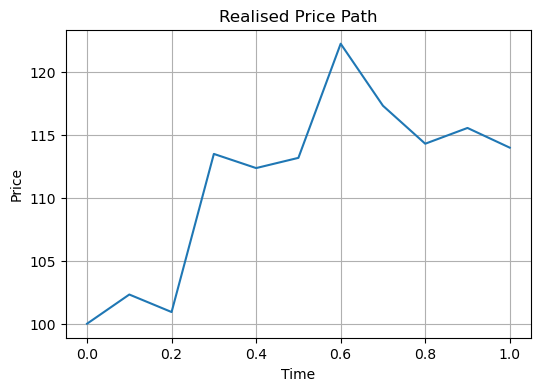

In [5]:
# Plot the realised price path
plt.figure(figsize=(6, 4))
plt.plot(time, S)
plt.title('Realised Price Path')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [6]:
# Calculate option price at time 0
delta = calculate_delta(S0, K, T, r, sigma, payoff='call')
bond_holding = calculate_bond_holding(S0, K, T, r, sigma, payoff='call')
V0 = delta * S0 + bond_holding

# Print results
print(f"### At t0 ###")
print(f"Stock price (S0): {S0:.2f}")
print(f"Option price (V0): {V0:.2f}")
print(f"Delta (delta): {delta:.2f}")
print(f"Buy delta * S0 of stock: {delta * S0:.2f}")
print(f"Financed by borrowing V0 - delta * S0 = bond_holding: {bond_holding:.2f}")

### At t0 ###
Stock price (S0): 100.00
Option price (V0): 8.03
Delta (delta): 0.63
Buy delta * S0 of stock: 63.37
Financed by borrowing V0 - delta * S0 = bond_holding: -55.34


In [7]:
# Rebalancing through time along the realised price path
deltas = np.zeros(N + 1)
bond_holdings  = np.zeros(N + 1)
V = np.zeros(N + 1)
for t in range(N + 1):
    tau = T - t * dt
    if tau <= 0:
        tau = 1e-8    # avoid divide by zero
    deltas[t] = calculate_delta(S[t], K, tau, r, sigma, 'call')
    bond_holdings[t]  = calculate_bond_holding(S[t], K, tau, r, sigma, 'call')
    V[t] = deltas[t] * S[t] + bond_holdings[t]

In [8]:
# Calculate realised option payoff at time T
ST = S[-1]
payoff_T = max(ST - K, 0)

# Print results
print(f"### At T ###")
print(f"Stock price (ST): {ST:.2f}")
print(f"Option terminal value (payoff_T): {payoff_T:.2f}")

### At T ###
Stock price (ST): 113.99
Option terminal value (payoff_T): 13.99


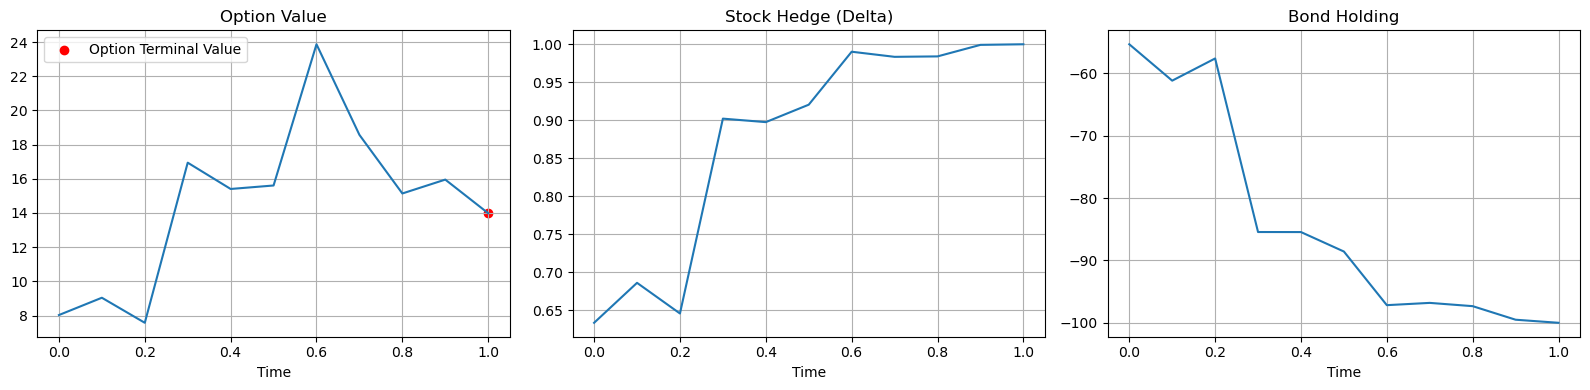

In [9]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(time, V)
plt.scatter(time[-1], payoff_T, color='red', label='Option Terminal Value')
plt.title('Option Value')
plt.xlabel('Time')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time, deltas)
plt.title('Stock Hedge (Delta)')
plt.xlabel('Time')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(time, bond_holdings)
plt.title('Bond Holding')
plt.xlabel('Time')
plt.grid(True)

plt.tight_layout()
plt.show()

In [10]:
# Create a df to show delta hedging over time
df = pd.DataFrame({
    'time': time,
    'stock_price': S,
    'option_value': V,
    'delta': deltas
})

# How many shares to trade each step
df['delta_change'] = df['delta'].diff()

# Cashflow from trading shares
# negative = you pay cash to buy shares
# positive = you receive cash from selling shares
df.loc[0, 'stock_trade_cashflow'] = -df.loc[0, 'delta'] * df.loc[0, 'stock_price']
df.loc[1:, 'stock_trade_cashflow'] = (-df.loc[1:, 'delta_change'] * df.loc[1:, 'stock_price'])

# Cash account (borrowing)
df['cash_account'] = 0.0

# t = 0 : receive option premium, then buy initial delta shares
df.loc[0, 'cash_account'] = V0 + df.loc[0, 'stock_trade_cashflow']

# Propagate through time with interest
for t in range(1, len(df)):
    df.loc[t, 'cash_account'] = (
        df.loc[t - 1, 'cash_account'] * np.exp(r * dt) + df.loc[t, 'stock_trade_cashflow']
    )

# Hedge portfolio value at each step
df['hedge_portfolio_value'] = (df['delta'] * df['stock_price'] + df['cash_account'])

df

,time,stock_price,option_value,delta,delta_change,stock_trade_cashflow,cash_account,hedge_portfolio_value
0,0.0,100.000000,8.028600,0.633699,NaN,-63.369912,-55.341312,8.028600
1,0.1,102.319415,9.041092,0.686255,0.052556,-5.377528,-60.940649,9.276603
2,0.2,100.927748,7.574933,0.645957,-0.040299,4.067245,-57.117655,8.077313
3,0.3,113.489066,16.942587,0.902189,0.256232,-29.079523,-86.426105,15.962453
4,0.4,112.364575,15.404218,0.897601,-0.004587,0.515456,-86.257046,14.601553
5,0.5,113.176434,15.607549,0.920521,0.022919,-2.593929,-89.196694,14.984561
6,0.6,122.243094,23.870051,0.990180,0.069659,-8.515327,-98.069523,22.973108
7,0.7,117.317385,18.568987,0.983460,-0.006720,0.788388,-97.674198,17.702707
8,0.8,114.299154,15.140690,0.984028,0.000569,-0.065011,-98.130688,14.342919
9,0.9,115.551691,15.952104,0.999199,0.015170,-1.752943,-100.276940,15.182142


In [11]:
print(f"Terminal hedging error: {df['hedge_portfolio_value'].iloc[-1] - payoff_T:.3f}")

Terminal hedging error: -0.770


This simulation demonstrates that dynamic delta hedging can approximately replicate the payoff of a European option. However, because hedging occurs at discrete intervals rather than continuously, a non-zero hedging error remains at expiry (which could be positive or negative). The magnitude of this error reflects the limitations of discrete rebalancing and the sensitivity of option value to nonlinear price movements. As the rebalancing frequency increases, the hedging error tends toward zero, consistent with Black–Scholes theory.

Let's look at another case where the option expires out of the money. 

In [12]:
# Simulate a realised price path
S = np.zeros(N + 1)
S[0] = S0
Z = ss.norm.rvs(loc=0, scale=1, size=N, random_state=6)
for t in range(1, N + 1):
    S[t] = S[t-1] * np.exp(mu * dt + sigma * np.sqrt(dt) * Z[t-1])

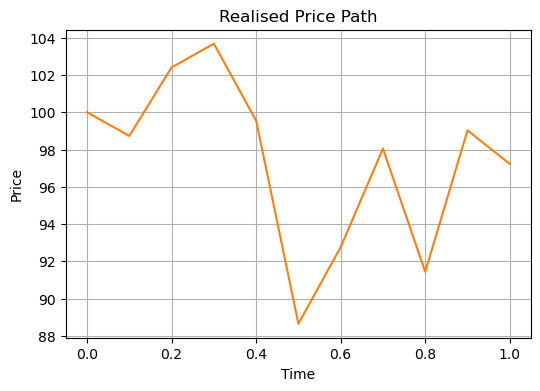

In [13]:
# Plot the realised price path
plt.figure(figsize=(6, 4))
plt.plot(time, S, color='C1')
plt.title('Realised Price Path')
plt.xlabel('Time')
plt.ylabel('Price')
plt.grid(True)
plt.show()

In [14]:
# Calculate option price at time 0
delta = calculate_delta(S0, K, T, r, sigma, payoff='call')
bond_holding = calculate_bond_holding(S0, K, T, r, sigma, payoff='call')
V0 = delta * S0 + bond_holding

# Print results
print(f"### At t0 ###")
print(f"Stock price (S0): {S0:.2f}")
print(f"Option price (V0): {V0:.2f}")
print(f"Delta (delta): {delta:.2f}")
print(f"Buy delta * S0 of stock: {delta * S0:.2f}")
print(f"Financed by borrowing V0 - delta * S0 = bond_holding: {bond_holding:.2f}")

### At t0 ###
Stock price (S0): 100.00
Option price (V0): 8.03
Delta (delta): 0.63
Buy delta * S0 of stock: 63.37
Financed by borrowing V0 - delta * S0 = bond_holding: -55.34


In [15]:
# Rebalancing through time along the realised price path
deltas = np.zeros(N + 1)
bond_holdings  = np.zeros(N + 1)
V = np.zeros(N + 1)
for t in range(N + 1):
    tau = T - t * dt
    if tau <= 0:
        tau = 1e-8    # avoid divide by zero
    deltas[t] = calculate_delta(S[t], K, tau, r, sigma, 'call')
    bond_holdings[t]  = calculate_bond_holding(S[t], K, tau, r, sigma, 'call')
    V[t] = deltas[t] * S[t] + bond_holdings[t]

In [16]:
# Calculate realised option payoff at time T
ST = S[-1]
payoff_T = max(ST - K, 0)

# Print results
print(f"### At T ###")
print(f"Stock price (ST): {ST:.2f}")
print(f"Option terminal value (payoff_T): {payoff_T:.2f}")

### At T ###
Stock price (ST): 97.22
Option terminal value (payoff_T): 0.00


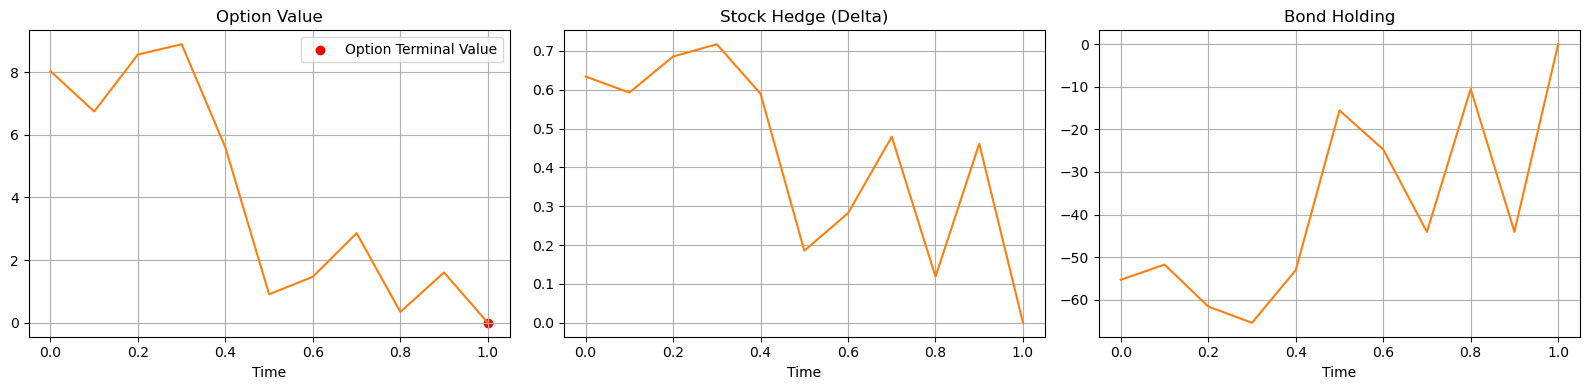

In [17]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
plt.plot(time, V, color='C1')
plt.scatter(time[-1], payoff_T, color='red', label='Option Terminal Value')
plt.title('Option Value')
plt.xlabel('Time')
plt.grid(True)
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(time, deltas, color='C1')
plt.title('Stock Hedge (Delta)')
plt.xlabel('Time')
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(time, bond_holdings, color='C1')
plt.title('Bond Holding')
plt.xlabel('Time')
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
# Create a df to show delta hedging over time
df = pd.DataFrame({
    'time': time,
    'stock_price': S,
    'option_value': V,
    'delta': deltas
})

# How many shares to trade each step
df['delta_change'] = df['delta'].diff()

# Cashflow from trading shares
# negative = you pay cash to buy shares
# positive = you receive cash from selling shares
df.loc[0, 'stock_trade_cashflow'] = -df.loc[0, 'delta'] * df.loc[0, 'stock_price']
df.loc[1:, 'stock_trade_cashflow'] = (-df.loc[1:, 'delta_change'] * df.loc[1:, 'stock_price'])

# Cash account (borrowing)
df['cash_account'] = 0.0

# t = 0 : receive option premium, then buy initial delta shares
df.loc[0, 'cash_account'] = V0 + df.loc[0, 'stock_trade_cashflow']

# Propagate through time with interest
for t in range(1, len(df)):
    df.loc[t, 'cash_account'] = (
        df.loc[t-1, 'cash_account'] * np.exp(r * dt) + df.loc[t, 'stock_trade_cashflow']
    )

# Hedge portfolio value at each step
df['hedge_portfolio_value'] = (df['delta'] * df['stock_price'] + df['cash_account'])

df

,time,stock_price,option_value,delta,delta_change,stock_trade_cashflow,cash_account,hedge_portfolio_value
0,0.0,100.000000,8.028600,0.633699,NaN,-63.369912,-55.341312,8.028600
1,0.1,98.729224,6.741883,0.592608,-0.041091,4.056847,-51.506274,7.001501
2,0.2,102.407575,8.560336,0.685424,0.092815,-9.504978,-61.217690,8.974886
3,0.3,103.678299,8.887144,0.716912,0.031488,-3.264607,-64.727658,9.600509
4,0.4,99.548520,5.591204,0.589286,-0.127626,12.704934,-52.282153,6.380393
5,0.5,88.649181,0.908890,0.185572,-0.403714,35.788936,-16.702765,-0.251981
6,0.6,92.759129,1.470031,0.282237,0.096665,-8.966554,-25.736264,0.443764
7,0.7,98.049009,2.860292,0.478995,0.196759,-19.291979,-45.131393,1.833611
8,0.8,91.436770,0.347224,0.118658,-0.360338,32.948113,-12.364167,-1.514507
9,0.9,99.028343,1.606829,0.461045,0.342388,-33.906100,-46.319823,-0.663265


In [19]:
print(f"Terminal hedging error: {df['hedge_portfolio_value'].iloc[-1] - payoff_T:.3f}")

Terminal hedging error: -1.681
